# Stability of wearing-position bias with sample size

Johannes Zauner

## Preface

The metric comparison established that wearing position (chest and
wrist, relative to the glasses reference) introduces an outcome-level
*bias* in light exposure metrics. This document asks a complementary,
design-oriented question:

> **If and when does the estimated bias stabilise as data accumulate?**

We probe this along two independent axes with bootstrapping:

1.  **Participants** — how the bias and its uncertainty behave as the
    number of participants grows (1–200, resampled with replacement).
2.  **Participant-days** — how they behave as the number of days *per
    participant* grows (1–7), holding the full participant set.

At each sample size we bootstrap the *mean bias* and summarise its
sampling variability by its **standard deviation**. Bias is computed on
each metric’s **model scale** (the scale on which the comparison
notebook analysed it) and expressed **in percent of the glasses
reference level**, so all six metrics share one interpretable axis. The
figure tracks that SD — the uncertainty in the estimated bias — as
sample size grows. A companion table then applies a practical **5%
tolerance**, reporting the sample size at which each metric’s bias SD
first falls to or below 5%, or noting that it never does.

The analysis uses one metric per metric category:

| Category (metric family/type) | Metric                        |
|-------------------------------|-------------------------------|
| Duration above threshold      | Duration above 250 lx mel EDI |
| Dose                          | Melanopic dose                |
| Mean level                    | Mean mel EDI                  |
| Spectral                      | MDER                          |
| Pulses                        | N pulses above 250 lx mel EDI |
| Timing                        | Brightest 10 h midpoint       |

## Setup

Packages for data wrangling (`tidyverse`), reading the metric metadata
(`readxl`), the model-scale transform `log_zero_inflated()`
(`LightLogR`), figures and tables (`cowplot`, `gt`), the
wearing-position color palette (`ggsci`), and project paths (`here`).

In [ ]:
#| label: setup
#| warning: false
#| message: false
#| filename: Setup
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Attaching package: 'cowplot'

The following object is masked from 'package:lubridate':

    stamp


Attaching package: 'gt'

The following object is masked from 'package:cowplot':

    as_gtable

here() starts at /Users/zauner/Documents/Arbeit/12-TUM/Repos_Misc/WearingPositionError_2026

The pre-processed metrics are loaded from the `.RData` file produced by
the preparation notebook. The object `metrics` is long-format with one
row per participant (`Id`), date (`Date`), wearing `position`, and
`metric`.

In [ ]:
#| label: import-metrics
#| filename: Import metrics
load(here("data/prepared_metrics.RData"))

A single seed is set for the whole notebook so every bootstrap is
reproducible.

In [ ]:
#| label: set-seed
#| filename: Set seed
set.seed(7391)

## Metric selection

We select one metric per category and confirm that each string is
actually present in the data.

In [ ]:
#| label: select-metrics
#| filename: Define and verify target metrics
target_metrics <- c(
  "duration_above_250",      # Duration above 250 lx mel EDI
  "dose",                    # Melanopic dose
  "mean_MEDI",               # Mean mel EDI
  "MDER",                    # MDER
  "n_pulses_above_250",      # N pulses above 250 lx mel EDI
  "brightest_10h_midpoint"   # Brightest 10 h midpoint
)

missing <- setdiff(target_metrics, unique(metrics$metric))
stopifnot("Some target metrics are absent from `metrics`" = length(missing) == 0)

metric_labels <- c(
  duration_above_250     = "Duration > 250 lx",
  dose                   = "Melanopic dose",
  mean_MEDI              = "Mean mel EDI",
  MDER                   = "MDER",
  n_pulses_above_250     = "N pulses > 250 lx",
  brightest_10h_midpoint = "Brightest 10h midpoint"
)

A shared, named palette assigns one color per wearing position, matching
the comparison notebook (`ggsci::pal_jco()`).

In [ ]:
#| label: position-colors
#| filename: Wearing-position palette
position_colors <- ggsci::pal_jco()(3) |> set_names(c("glasses", "chest", "wrist"))

## Model scale of each metric

Bias must be computed on the same scale each metric was modelled on in
the comparison notebook. That scale is derived from the metric metadata
in `data/metric_types.xlsx` using the same logic as the comparison
notebook: a log-transformed response or a `glmmTMB`/Poisson engine
implies a (base-10 or natural) log scale, a `qlogis` response implies a
logit scale, and everything else is linear. `derive_metric_scales()`
(sourced below) returns, per metric, the scale and the `transform` that
brings the *stored* value onto it — `identity` where the value is
already on scale (e.g. `mean_MEDI`, stored as the mean of
`log_zero_inflated(MEDI)`).

In [ ]:
#| label: load-metric-info
#| filename: Load metric metadata
metric_info <- read_xlsx(here("data/metric_types.xlsx"))

## Defining the bias

For each metric we transform values to the model scale, align the three
positions on the same participant-day, and compute the bias of each
comparison position (chest, wrist) against the glasses reference:

$$\text{bias} = \text{value}^{\text{model}}_{\text{position}} - \text{value}^{\text{model}}_{\text{glasses}}$$

To make metrics comparable, bias is expressed **in percent of the
glasses reference level** — the model-scale bias divided by the absolute
mean model-scale glasses value, matching the comparison notebook’s
“outcome-level bias (%)”. Note that on a log scale this is the ratio of
a log-difference to a log-level, so the logarithm base cancels and
`log_zero_inflated()` (zero-safe, base-10) can be used throughout. The
illustrative table below shows, for one metric, the per-position bias on
the model scale alongside the reference level.

In [ ]:
#| label: bias-table-manual
#| filename: Build the bias table (illustrative, single metric)
metrics |>
  filter(metric == "dose", position %in% c("glasses", "chest", "wrist")) |>
  mutate(value = log_zero_inflated(value)) |>
  select(metric, site, Id, Date, position, value) |>
  pivot_wider(names_from = position, values_from = value) |>
  mutate(bias_chest = chest - glasses,
         bias_wrist = wrist - glasses) |>
  head()

# A tibble: 6 × 9
  metric site  Id        Date       chest glasses wrist bias_chest bias_wrist
  <chr>  <chr> <chr>     <date>     <dbl>   <dbl> <dbl>      <dbl>      <dbl>
1 dose   BAUA  BAUA_S001 2025-06-11  4.62    4.63 4.63     -0.0137  -0.000909
2 dose   BAUA  BAUA_S001 2025-06-12  3.89    3.84 4.15      0.0429   0.302   
3 dose   BAUA  BAUA_S001 2025-06-13  4.63    3.98 4.78      0.651    0.794   
4 dose   BAUA  BAUA_S001 2025-06-14  4.29    3.97 4.57      0.315    0.593   
5 dose   BAUA  BAUA_S001 2025-06-15  1.23    3.18 0.824    -1.95    -2.36    
6 dose   BAUA  BAUA_S001 2025-06-16  4.06    4.04 4.04      0.0216   0.00331 

## Testing the approach

Before generalising, we validate the full pipeline on a **single metric
(`dose`)** with a **small number of bootstraps (B = 20)**. This keeps
the logic transparent and confirms the end-to-end path (model-scale bias
→ bootstrap → median and 90% interval in percent) behaves sensibly
before the expensive full run.

First, the model-scale bias table for the test metric, in long form (one
row per participant-day and comparison position). `dose` is on a log10
scale, so values are passed through `log_zero_inflated()`; the reference
level `ref` is the absolute mean model-scale glasses value, used to
convert bias to percent.

In [ ]:
#| label: test-bias
#| filename: Test bias table (single metric)
test_ms <-
  metrics |>
  filter(metric == "dose", position %in% c("glasses", "chest", "wrist")) |>
  mutate(value = log_zero_inflated(value))

test_ref <- test_ms |> filter(position == "glasses") |> summarise(abs(mean(value))) |> pull()

test_bias <-
  test_ms |>
  select(metric, site, Id, Date, position, value) |>
  pivot_wider(names_from = position, values_from = value) |>
  pivot_longer(c(chest, wrist), names_to = "position", values_to = "value_pos") |>
  mutate(bias = value_pos - glasses) |>
  filter(!is.na(bias)) |>
  select(metric, position, site, Id, Date, bias)

**Participant axis (test).** For a handful of sample sizes, we collapse
each participant to their mean bias, resample participants with
replacement, and take the standard deviation (in percent of `ref`) of
the resampled mean across B = 20 replicates.

In [ ]:
#| label: test-participants
#| filename: Test participant bootstrap
test_A <-
  test_bias |>
  group_by(metric, position) |>
  group_modify(\(d, key) {
    per_id <- d |> group_by(Id) |> summarise(mb = mean(bias), .groups = "drop") |> pull(mb)
    map_dfr(c(1, 5, 25, 100, 200), \(n) {
      est <- replicate(20, mean(sample(per_id, n, replace = TRUE)))
      tibble(n = n, sd = sd(est) * 100 / test_ref)
    })
  }) |>
  ungroup()

test_A

# A tibble: 10 × 4
   metric position     n    sd
   <chr>  <chr>    <dbl> <dbl>
 1 dose   chest        1 4.08 
 2 dose   chest        5 2.13 
 3 dose   chest       25 1.25 
 4 dose   chest      100 0.386
 5 dose   chest      200 0.310
 6 dose   wrist        1 7.94 
 7 dose   wrist        5 3.28 
 8 dose   wrist       25 1.55 
 9 dose   wrist      100 0.592
10 dose   wrist      200 0.536

**Participant-day axis (test).** For each participant we resample
`n_days` of their days with replacement, average, then average across
participants; the standard deviation across B = 20 replicates is
recorded for 1–7 days.

In [ ]:
#| label: test-days
#| filename: Test participant-day bootstrap
test_B <-
  test_bias |>
  group_by(metric, position) |>
  group_modify(\(d, key) {
    by_id <- split(d$bias, d$Id)
    map_dfr(1:7, \(nd) {
      est <- replicate(20, mean(map_dbl(by_id, \(v) mean(sample(v, nd, replace = TRUE)))))
      tibble(n = nd, sd = sd(est) * 100 / test_ref)
    })
  }) |>
  ungroup()

A quick sanity plot of the participant axis: the standard deviation of
the bias (the uncertainty in the estimate) shrinks steeply with more
participants, toward the 5% tolerance.

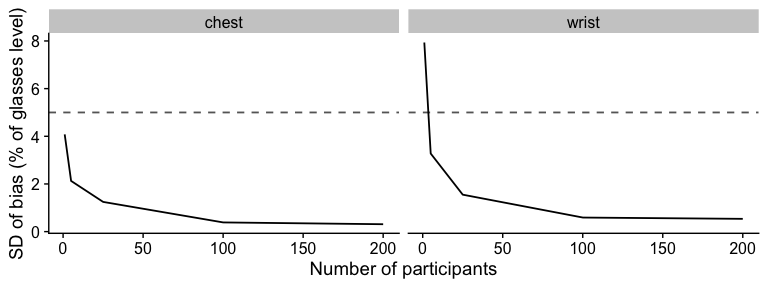

In [ ]:
#| label: fig-test
#| filename: Sanity plot of the test run
#| fig-width: 8
#| fig-height: 3
test_A |>
  ggplot(aes(n, sd)) +
  geom_hline(yintercept = 5, linetype = "dashed", colour = "grey40") +
  geom_line() +
  facet_wrap(~position) +
  labs(x = "Number of participants", y = "SD of bias (% of glasses level)") +
  theme_cowplot()

The approach is sound: the estimate’s uncertainty shrinks with data. We
now generalise.

## Generalising into reusable functions

The test logic is repeated identically across all six metrics and both
positions, so it is factored into `scripts/bootstrap_stability.R`.
Sourcing it exposes the functions used below:

- **`derive_metric_scales()`** — maps the metric metadata to a model
  scale and a value `transform` (`log_zero_inflated` / `qlogis` /
  `identity`).
- **`compute_bias()`** — transforms values to the model scale, then
  builds the long bias table (comparison − glasses) per participant-day,
  attaching the per-metric percent reference `ref`.
- **`boot_participants()`** — the participant axis: collapses each
  participant to their mean bias and resamples participants with
  replacement, returning the SD in percent.
- **`boot_days()`** — the participant-day axis: draws a fixed number of
  participants (default 50) with replacement, resamples `n_days` per
  participant, and averages (same summary).
- **`bootstrap_stability()`** — runs both axes and binds them into one
  tidy table.
- **`crossing_table()`** — the smallest sample size at which the bias SD
  falls to or below 5%.
- **`plot_stability()` / `color_strips_grid()`** — the four-panel figure
  and its position-colored strips.

In [ ]:
#| label: source-functions
#| filename: Source bootstrap-stability helpers
source(here("scripts/bootstrap_stability.R"))

The model scale and transform for each target metric:

In [ ]:
#| label: metric-scales
#| filename: Derive model scales
scales <- derive_metric_scales(metric_info)
scales |> filter(metric %in% target_metrics)

# A tibble: 6 × 4
  metric                 scaling already_scaled transform        
  <chr>                  <chr>   <lgl>          <chr>            
1 mean_MEDI              log10   TRUE           identity         
2 brightest_10h_midpoint linear  FALSE          identity         
3 duration_above_250     log     FALSE          log_zero_inflated
4 n_pulses_above_250     log     FALSE          log_zero_inflated
5 dose                   log10   FALSE          log_zero_inflated
6 MDER                   linear  FALSE          identity         

The model-scale bias table for all six metrics and both comparison
positions:

In [ ]:
#| label: bias-all
#| filename: Bias table for all target metrics
bias_df <- compute_bias(metrics |> filter(metric %in% target_metrics), scales)
bias_df |> count(metric, position)

# A tibble: 12 × 3
   metric                 position     n
   <chr>                  <chr>    <int>
 1 MDER                   chest      602
 2 MDER                   wrist      602
 3 brightest_10h_midpoint chest      604
 4 brightest_10h_midpoint wrist      604
 5 dose                   chest      604
 6 dose                   wrist      604
 7 duration_above_250     chest      604
 8 duration_above_250     wrist      604
 9 mean_MEDI              chest      604
10 mean_MEDI              wrist      604
11 n_pulses_above_250     chest      604
12 n_pulses_above_250     wrist      604

## Full bootstrap run

We now run both axes for every metric and position with **B = 1000**
replicates, across participants 1–200 and participant-days 1–7. The
participant-days axis is based on a fixed study size, set here; unlike
the participant axis (which varies the number of people), it asks how
days-per-person alone affect precision for a study of this size.

In [ ]:
#| label: days-n
#| filename: Fixed study size for the participant-days axis
days_n_participants <- 50

The chunk is cached because the full run is the expensive step;
re-renders reuse the stored result.

In [ ]:
#| label: full-run
#| filename: Full bootstrap run
#| cache: true
stability <- bootstrap_stability(
  bias_df,
  n_range             = 1:200,
  day_range           = 1:7,
  B                   = 1000,
  days_n_participants = days_n_participants
)

## Stabilisation figure

The four panels cross the two comparison positions (rows, strip color =
position) with the two bootstrap axes (columns). Each metric is a single
line showing the **standard deviation of its bias** (in percent of the
glasses level) — a direct measure of how uncertain the estimated bias is
at a given sample size. The dashed reference marks the 5% SD tolerance.
The x-axes are free: the participant column spans 1–200, while the
participant-day column shows 1–7 days. The participant-days panels are
based on 50 participants (noted in the figure caption), so they isolate
the effect of days-per-person at a fixed study size. The y-axis is
clipped so the very large SDs at the smallest samples are cut off.

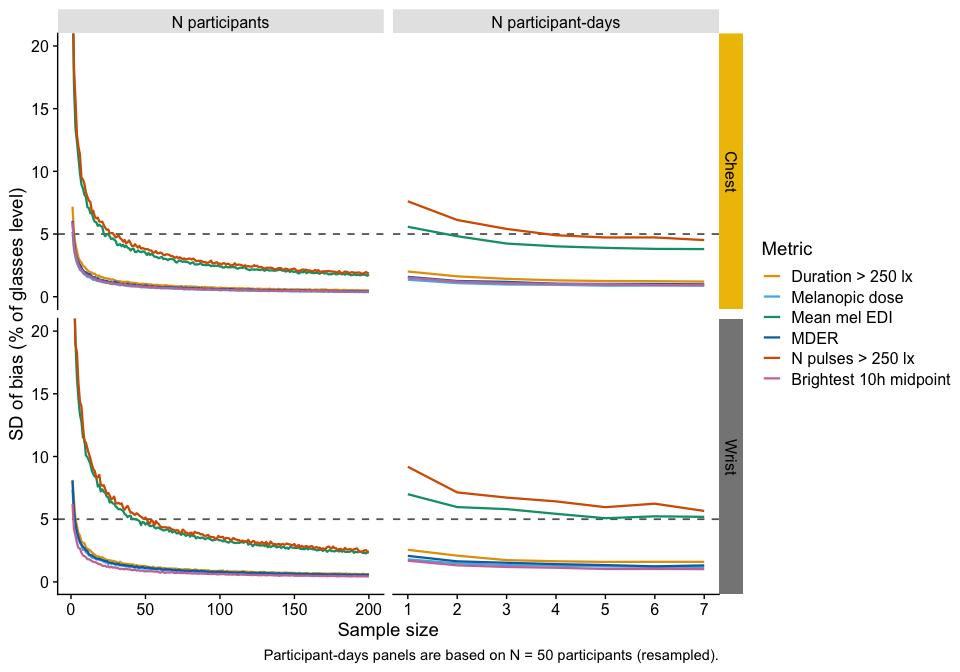

In [ ]:
#| label: fig-stability
#| filename: Four-panel stability figure
#| fig-width: 10
#| fig-height: 7
#| warning: false
fig_stability <- plot_stability(stability, position_colors, metric_labels,
                                tol = 5, ylim = c(0, 20),
                                days_n_participants = days_n_participants)
fig_stability

In [ ]:
#| label: save-figure
#| filename: Save the stability figure
ggsave(here("output/figures/Fig_bias_stability.pdf"), fig_stability,
       width = 10, height = 7, device = cairo_pdf)
ggsave(here("output/figures/Fig_bias_stability.jpeg"), fig_stability,
       width = 10, height = 7)

## When does the bias SD fall to 5%?

The table below reports, for each metric, wearing position, and
bootstrap axis, the smallest sample size at which the bias SD first
falls to or below 5% of the glasses level. `never` means the SD stays
above 5% throughout the tested range.

In [ ]:
#| label: tbl-crossing
#| filename: Sample size to reach 5% SD
crossing_table(stability, tol = 5) |>
  mutate(metric = recode(metric, !!!metric_labels),
         n_within = as.character(n_within)) |>
  replace_na(list(n_within = "never")) |>
  pivot_wider(names_from = c(boot_type, position), values_from = n_within,
              names_sep = " / ") |>
  gt(rowname_col = "metric") |>
  tab_header("Sample size for bias SD ≤ 5%") |>
  tab_spanner_delim(delim = " / ") |>
  sub_missing(missing_text = "never")

## Interpretation

The figure isolates *precision*: the point bias of each metric is a
property of the population and barely moves with sample size, so the
bias SD shows purely how uncertain that estimate is. It falls steeply
with participants and more gently with participant-days, approaching a
between-participant floor that extra days cannot cross.

Because the SD measures spread rather than magnitude, it reaches the 5%
tolerance for every metric once enough data accumulate — even metrics
with a large point bias such as mean mel EDI, whose estimate is simply
*precise* at a non-zero value. The participant axis buys precision far
faster than the participant-day axis: a few dozen participants bring
most metrics’ SD below 5%, whereas extending days per participant helps
only up to the between-participant floor. The crossing table quantifies
these thresholds; note that a small SD confirms the bias is well
*estimated*, not that it is small — the magnitude must be read from the
comparison notebook.

## Session info

In [ ]:
#| label: session-info
sessionInfo()

R version 4.5.0 (2025-04-11)
Platform: aarch64-apple-darwin20
Running under: macOS 26.5.2

Matrix products: default
BLAS:   /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.0.dylib 
LAPACK: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRlapack.dylib;  LAPACK version 3.12.1

locale:
[1] en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/en_US.UTF-8

time zone: Europe/Berlin
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices datasets  utils     methods   base     

other attached packages:
 [1] here_1.0.2       gt_1.3.0         cowplot_1.2.0    LightLogR_0.10.0
 [5] readxl_1.4.5     lubridate_1.9.5  forcats_1.0.1    stringr_1.6.0   
 [9] dplyr_1.2.1      purrr_1.2.2      readr_2.2.0      tidyr_1.3.2     
[13] tibble_3.3.1     ggplot2_4.0.2    tidyverse_2.0.0 

loaded via a namespace (and not attached):
 [1] sass_0.4.10        utf8_1.2.6         generics_0.1.4     renv_1.1.4        
 [5] xml2_1.5.2         strin